In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os

#to get font to work
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]


In [10]:
#This file has pearson correlation and rsq for prediction results
pearson_df = pd.read_csv('/home/mbrannon/tmp/new_vinson_results.csv')

In [11]:
import pandas as pd
from genome_tools.data.anndata import read_zarr_backed

adata = read_zarr_backed(
    "/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr"
)

required_cols = ["extended_annotation", "pathological_state"]
for col in required_cols:
    if col not in adata.obs.columns:
        raise ValueError(f"{col} column not found in adata.obs")

extended_df = adata.obs[required_cols].copy()
extended_df["agid"] = extended_df.index  # index is AGID



Loaded adata with shape: (4159, 5331170)
obs index example: Index(['AG10028', 'AG10029', 'AG10031', 'AG10032', 'AG10033'], dtype='object', name='ag_id')


In [12]:
merged_df = pearson_df.merge(
    extended_df,
    left_on="sample_id",
    right_on="agid",
    how="left"
)

In [13]:
merged_df = merged_df.rename(columns={'sample_id':'ag_id'})

In [14]:
merged_df

,prefix,ag_id,mode,model_config,model_type,checkpoint,dhs_dataset,result_np,pearson,r2,extended_annotation,pathological_state,agid
0,AG10697_sample_dhs,AG10697,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.877167,0.769422,Pluripotent/Pluripotent-derived,Normal,AG10697
1,AG12379_sample_dhs,AG12379,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.837814,0.701932,Bone marrow,Normal,AG12379
2,AG15858_sample_dhs,AG15858,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.764802,0.584922,Cerebellum,Normal,AG15858
3,AG3830_sample_dhs,AG3830,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.829412,0.687924,CMP,Normal,AG3830
4,AG3832_sample_dhs,AG3832,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.888048,0.788629,CMP,Normal,AG3832
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068,AG93421_sample_dhs,AG93421,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.813184,0.661269,T-cell,Normal,AG93421
2069,AG93505_sample_dhs,AG93505,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.821621,0.675061,T-cell,Normal,AG93505
2070,AG93570_sample_dhs,AG93570,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.879019,0.772674,NK-cell,Normal,AG93570
2071,AG93493_sample_dhs,AG93493,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.814791,0.663884,T-cell,Normal,AG93493


In [18]:
#add colors to match 
#mouse
#ann data colors
mouse_colors = {
    'AML':"#8977a6",
    "Adipose": "#feff55", 
    "Adrenal": "#6ce2fb",
    "Blastoma": "#e091a9",
    "Bladder":"#ffde59",
    "B-cell": "#eb5a4f",
    'Brain':"#fadce5",
    "Cerebellum":"#0e00a0",
    "Cerebrum":"#0e00a5",
    "Cerebral cortex":"#90fcb3",
    "Embryonic germ layer":"#a1659e",
    "Erythroid":"#520b0b",
    "Eye":"#849693",
    "Fibroblast":"#26430e",
    'Forebrain':"#fadce5",
    "Heart":"#71c43b",
    "Hindbrain":"#71c43b",
    "Kidney":"#d7800c",
    "Large intestine":"#483c51",
    "Limbic system":"#133247",
    "Lung":"#aa2617",
    "Midbrain":"#6f7822",
    "Limbic System":"#4dadfe",
    "Liver":"#fadce5",
    "Lymphoma":"#ff0036",
    "Monocyte":"#f4af97",
    "Muscle":"#f195c6",
    "NK-cell":"#e1eefe",
    "Ovary":"#75524d",
    "Pluripotent/Pluripotent-derived":"#2b0316",
    "Stomach":"#458e7d",
    "T-cell":"#f4b840",
    "Testis":"#cefeed",
}

In [15]:
#add colors to match human
#ann data colors
human_colors = {
    "ALL":"#77a69e",
    'AML':"#8977a6",
    'APL':"#a69077",
    "Adipose": "#feff55",  
    "Adrenal": "#6ce2fb",
    'Astrocyte':"#eb49f8",
    "Blastoma": "#e091a9",
    "B-cell": "#eb5a4f",
    "Basal ganglia":"#3c884a",
    "Bladder":"#ffde59",
    "Bone":"#306da1",
    'Bone marrow':"#951d58",
    'Brain stem':"#fadce5",
    "CMP":"#734b16",
    "CML":"#a1659e",
    "Carcinoma":"#96ce72",
    "Cerebellum":"#0e00a0",
    "Cerebral cortex":"#90fcb3",
    "Colon":"#b39869",
    "Dendritic":"#1e4c43",
    "Endothelium":"#96affa",
    "Epithelium":"#957e86",
    "Erythroid":"#520b0b",
    "Eye":"#849693",
    "Liposarcoma":"#5c3948",
    "Fetal life support":"#633c4d",
    "Fibroblast":"#26430e",
    "Gallbladder":"#d8d930",
    "Heart":"#71c43b",
    "Hepatic":"#71c43b",
    "Intestine":"#483c51",
    "Limbic system":"#61615b",
    "Lymphoma":"#d7800c",
    "Kidney":"#d7800c",
    "Lung":"#aa2617",
    "Macrophage":"#6f7822",
    "Mammary adenocarcinoma":"#4dadfe",
    "Mammary ductal carcinoma":"#fadce5",
    "Melanocyte":"#57bfa2",
    "Myoblast":"#aa24a4",
    "Myeloma":"#e7d2d9",
    "Myocyte":"#c36726",
    "Monocyte":"#f4af97",
    "Muscle":"#f195c6",
    "NK-cell":"#e1eefe",
    "Nerve":"#010032",
    "Non-SCLC":"#bf564a",
    "Ovary":"#75524d",
    "Pancreas":"#a7c19d",
    "Plasmacytoma":"#ff0036",
    "Pluripotent/Pluripotent-derived":"#2b0316",
    "Prostate":"#2b0316",
    "Rhaboid tumor":"#63545b",
    "SCLC":"#7b678a",
    "Sarcoma":"#5c394c",
    "Spinal cord":"#133247",
    "Stomach":"#458e7d",
    "Stroma":"#352207",
    "T-cell":"#f4b840",
    "Testis":"#cefeed",
    "Thyroid":"#9a7bbb",
    "Ureter":"#a7b717",
    "Uterus":"#bb2948",
}

In [18]:
merged = merged_df


In [19]:
#add custom colors
annotation_colors = human_colors
merged["color"] = merged["extended_annotation"].map(annotation_colors)

#sort by annotation
merged = merged.sort_values(by=["extended_annotation", "ag_id"])

# Make ag_id a categorical variable with this sorted order
merged["ag_id"] = pd.Categorical(
    merged["ag_id"], 
    categories=merged["ag_id"].unique(), 
    ordered=True
)

/tmp/slurm.7676118/ipykernel_2016005/3976887562.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("extended_annotation")["pearson"]


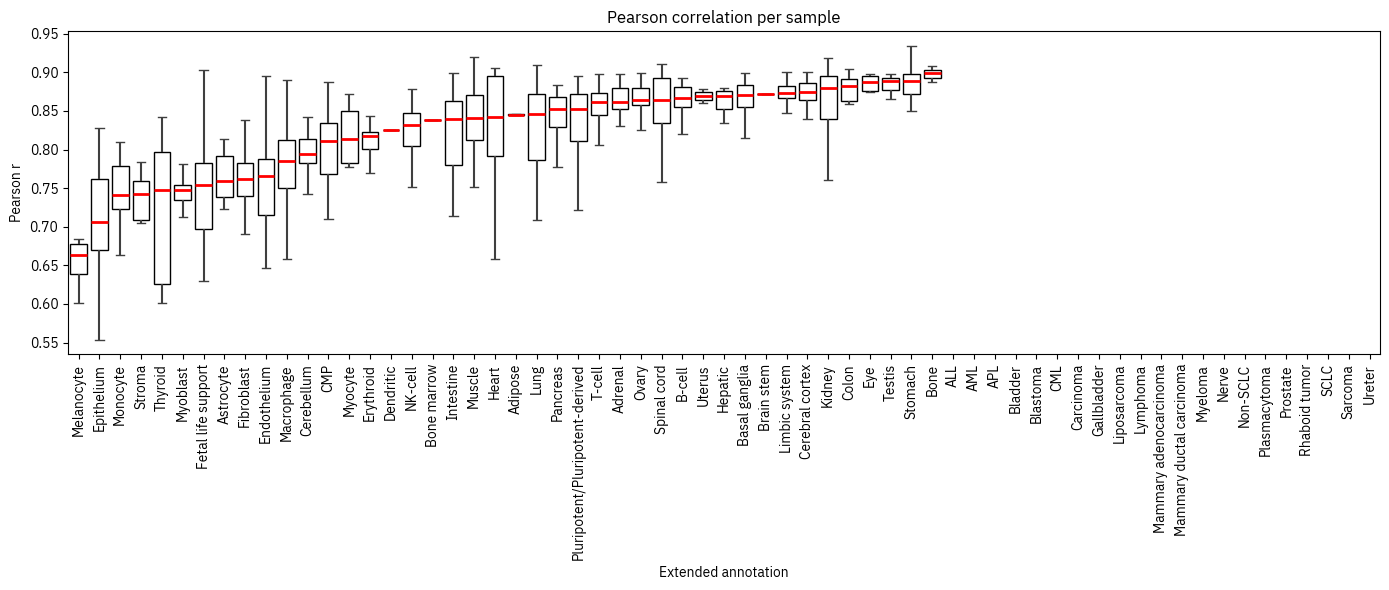

In [21]:
# Compute combined order by median correlation
order = (
    merged.groupby("extended_annotation")["pearson"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(14, 6))

# Boxplot (overall distribution)
sns.boxplot(
    data=merged,
    x="extended_annotation",
    y="pearson",
    order=order,
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2}
)

plt.xticks(rotation=90)
plt.xlabel("Extended annotation")
plt.ylabel("Pearson r")
plt.title("Pearson correlation per sample")

#plt.legend(title="Training Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/slurm.7676118/ipykernel_2016005/1367707287.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  valid_normal = normal_df.groupby("extended_annotation")["pearson"].count() > 0
/tmp/slurm.7676118/ipykernel_2016005/1367707287.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  valid_cancer = cancer_df.groupby("extended_annotation")["pearson"].count() > 0
/tmp/slurm.7676118/ipykernel_2016005/1367707287.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

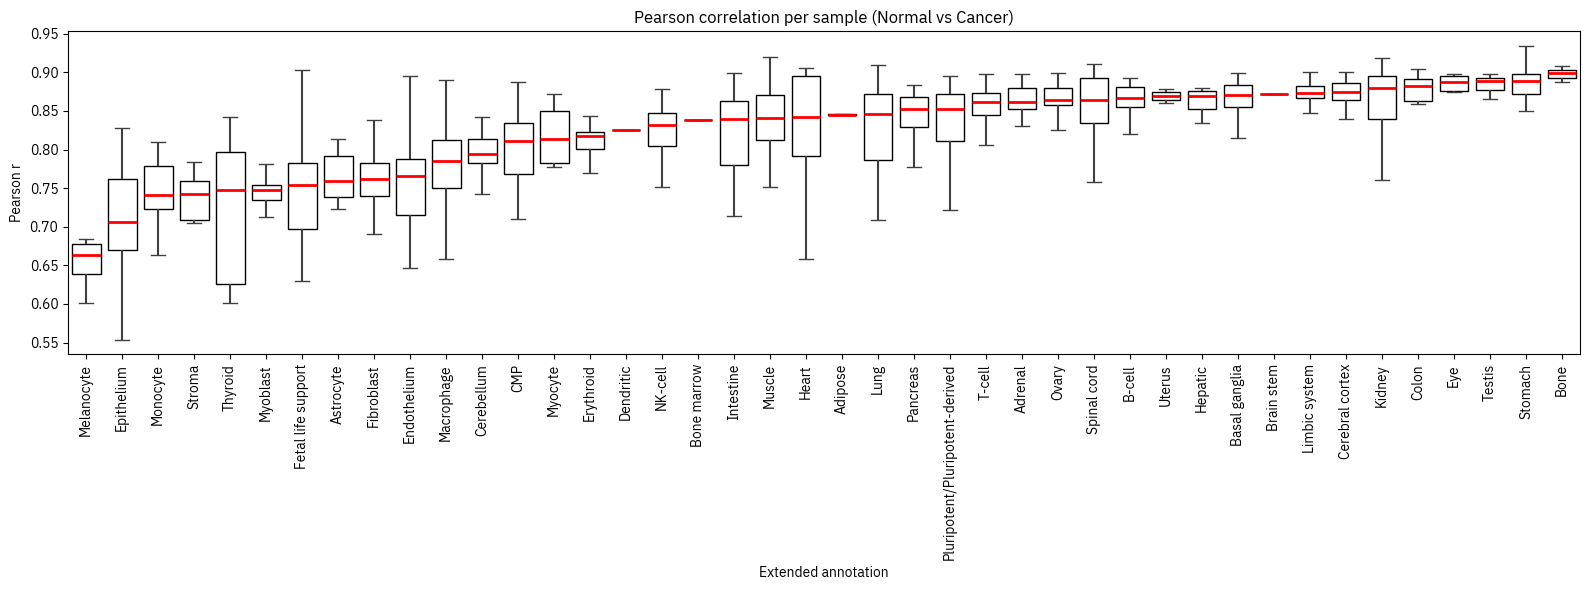

In [22]:
normal_df = merged[merged["pathological_state"] == "Normal"]
cancer_df = merged[merged["pathological_state"] == "Cancer"]

#Filter out annotations with no data
valid_normal = normal_df.groupby("extended_annotation")["pearson"].count() > 0
valid_cancer = cancer_df.groupby("extended_annotation")["pearson"].count() > 0

# Compute order separately
order_normal = normal_df.groupby("extended_annotation")["pearson"].median()[valid_normal].sort_values().index
order_cancer = cancer_df.groupby("extended_annotation")["pearson"].median()[valid_cancer].sort_values().index

# Combine order: Normal first, then Cancer
combined_order = list(order_normal) + list(order_cancer)

# --------------------------------------
# 4. Plot
# --------------------------------------
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=merged,
    x="extended_annotation",
    y="pearson",
    order=combined_order,
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2}
)

plt.xticks(rotation=90)
plt.xlabel("Extended annotation")
plt.ylabel("Pearson r")
plt.title("Pearson correlation per sample (Normal vs Cancer)")

plt.tight_layout()
plt.show()


In [23]:
plt.figure(figsize=(12, 6))

alpha_vals = (merged["SPOT3_score"] - merged["SPOT3_score"].min()) / (
    merged["SPOT3_score"].max() - merged["SPOT3_score"].min()
)
alpha_vals = 0.2 + 0.8 * alpha_vals  # ensures min alpha=0.2, max alpha=1

sns.scatterplot(
    data=merged,
    x="SPOT3_score",
    y="pearson_r",
    hue="extended_annotation",
    palette=annotation_colors,
    s=100,
    linewidth=0.1,
    edgecolor="none",
    alpha=alpha_vals
)

plt.xlabel("SPOT3_score")
plt.ylabel("Pearson r")
plt.title("Pearson correlation vs SPOT3_score")
plt.legend(title="Extended annotation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


KeyError: 'SPOT3_score'

<Figure size 1200x600 with 0 Axes>

In [24]:
# Subset to B cells
cell_type = "Erythroid"
cell_df = merged[merged["extended_annotation"].str.contains(cell_type, case=False, na=False)].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cell_df,
    x="SPOT3_score",
    y="pearson_r",
    hue="training_status",   # optional: color by training status if column exists
    s=80,
    alpha=0.8
)

plt.xlabel("SPOT3 Score")
plt.ylabel("Pearson r")
plt.title(f"{cell_type} Samples: Pearson correlation vs SPOT3 score")
plt.legend(title="Status")
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `SPOT3_score` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>